In [11]:
#Importing many things again 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [4]:
#Read and clean the data
df=pd.read_csv("/Users/melodyqian/Documents/GitHub/FindMyNuclearWaste/data/MLDataset.csv")
dummydf = pd.get_dummies(df, columns=['Urban_Rural'], drop_first=True)
dummydf= dummydf[dummydf['house_value_median']>0]
dummydf=dummydf[dummydf['county_data']==0]
admin= ['household_income_median','nonhispanic_percent', 'white_percent','missing_race','county_data', 'index', ]
dummydf = dummydf.drop(columns=admin, axis=1)

#print(dummydf)

In [ ]:
#Define and get rid of NA
y = dummydf['site']                    
X = dummydf.drop(columns=['site'])
X = X.fillna(X.median(numeric_only=True))

In [ ]:
#Separate data, build random forest
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=800,        # plenty of trees
    max_depth=8,            # cap depth (try 8, 12, 20)
    min_samples_leaf=8,      # avoid tiny leaves (try 2–10)
    min_samples_split=12,     # slightly larger internal nodes
    max_features="sqrt",     # strong default for classification
    class_weight="balanced",
    oob_score=True) 

In [ ]:
#Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_tr, y_tr, cv=cv, scoring="accuracy")
print(f"CV accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")


CV accuracy: 0.909 ± 0.077


In [ ]:
#Fit model and evaluate accuracy scores for test and training data
rf.fit(X_tr, y_tr)
y_pred = rf.predict(X_te)
print("RF train acc:", rf.score(X_tr, y_tr), "test acc:", accuracy_score(y_te, rf.predict(X_te)))

RF train acc: 0.9772727272727273 test acc: 0.9090909090909091


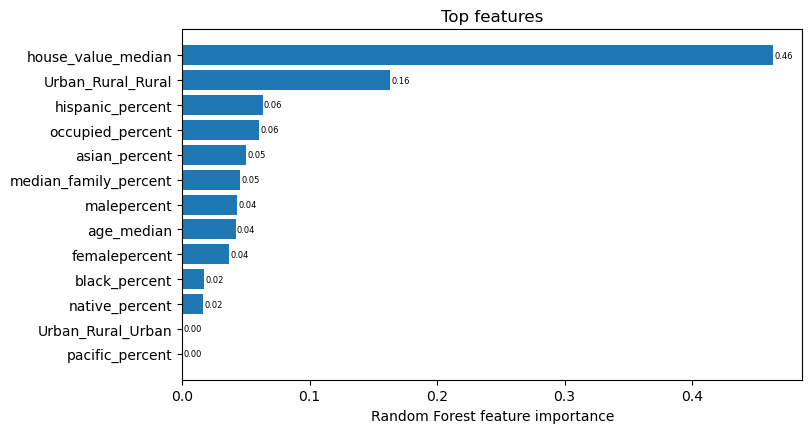

<Figure size 800x455 with 0 Axes>

In [47]:
#Plot feature importances.
import matplotlib.pyplot as plt

importances = rf.feature_importances_
order = np.argsort(importances)[::-1]

feature_names = np.asarray(X.columns)
names_sorted = feature_names[order]
imps_sorted = importances[order]


fig, ax = plt.subplots(figsize=(8, max(4, N*0.35)))
N = min(25, len(imps_sorted))

plt.figure(figsize=(8, max(4, N*0.35)))
bars=ax.barh(range(N), imps_sorted[:N])
ax.set_yticks(range(N), names_sorted[:N])
ax.invert_yaxis()
ax.set_xlabel("Random Forest feature importance")
ax.set_title("Top features")
ax.bar_label(bars, fmt="%.2f", padding=1, fontsize=6)
plt.tight_layout()
plt.show()